In [2]:
# Load core libraries and utilities
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Jupyter notebook "magic"
%matplotlib inline

## Image Compression through Singular Value Decomposition

As a first step into data science, we now look at how to compress an image using singular-value decomposition (SVD).  To do this, we first need to import an image that is then stored as a NumPy matrix.  In code, this matrix is called `dog_grayscale`, but mathematically we stick with our typical convention and refer to the matrix as $A$.  

In [3]:
# Find, load, and convert image from textbook data
dog_grayscale = io.imread('beans.jpg', as_gray=True)
print(type(dog_grayscale))

<class 'numpy.ndarray'>


For consistency, we need to rescale the values in `dog_grayscale`/${\bf A}$ to lie between $0$ and $1$.  We'd also like to be able to compare the results of various methods we apply so that we can build a more intuitive understanding of how mathematical formalism appears in practice.  

In [4]:
# We need a tool that converts images into grayscale (i.e. all pixel values in [0, 1])
def gray_scale_convert(image):
    rescaled_image = np.zeros((image.shape[0], image.shape[1]))
    rescaled_image[:, :] = image
    rescaled_image -= np.min(rescaled_image)
    rescaled_image /= np.max(rescaled_image)
    return rescaled_image

In [5]:
# We would like to easily comapre different images to one another after we do various things to them.  
def image_comparison(original_image, reduced_image):
    gscale_reduced_image = gray_scale_convert(reduced_image)
    difference = np.abs( original_image - gscale_reduced_image )

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    ax = axes.ravel()
    ax[0].imshow(original_image, cmap=plt.cm.gray)
    ax[0].set_title("Original")
    ax[1].imshow(gscale_reduced_image, cmap=plt.cm.gray) 
    ax[1].set_title("Reduced")
    ax[2].imshow(difference, cmap=plt.cm.gray)
    ax[2].set_title("Difference")
    fig.tight_layout()

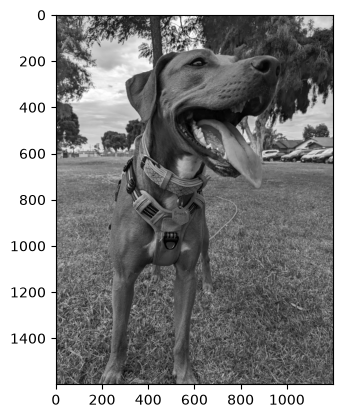

In [6]:
# BEANS TIME!
plt.imshow(dog_grayscale, cmap=plt.cm.gray)

Thinking now of our image as the matrix $A$, we can of course write said matrix as a collection of columns so that for $m\times n$ matrix ${\bf A}$ we have  
$$
{\bf A} = \left(\left.{\bf a}_{1}\right| \cdots \left| {\bf a}_{n}\right. \right), ~ {\bf a}_{j}\in \mathbb{R}^{m}.
$$
Next, we compute the average across columns, say $\boldsymbol{\mu}$ so that 
$$
\boldsymbol{\mu} = \frac{1}{n}\sum_{j=1}^{n}{\bf a}_{j}.
$$
We then look at the affiliated matrix ${\bf \tilde{A}}$ where 
$$
{\bf \tilde{A}} = \left(\left.{\bf a}_{1}-\boldsymbol{\mu}\right| \cdots \left| {\bf a}_{n}-\boldsymbol{\mu}\right. \right).
$$
The difference between ${\bf A}$ and ${\bf \tilde{A}}$ is that by centering around the column mean, we are tracking how much each column of the image varies around the average of the image.  


From here, we compute the SVD of ${\bf \tilde{A}}$ given by 
$$
{\bf \tilde{A}} = {\bf U}\boldsymbol{\Sigma} {\bf V}^{T}.
$$
The columns of ${\bf U}$ are typically called *principal components* as they represent an orthonormal basis along which the variance in ${\bf A}$ is localized.  To see this, we note that 
$$
{\bf \tilde{A}}{\bf \tilde{A}}^{T} = {\bf U}\boldsymbol{\Sigma}^{2}{\bf U}^{T}.
$$
Taking the trace of both sides gets us 
$$
\text{tr}\left({\bf \tilde{A}}{\bf \tilde{A}}^{T}\right) = \sum_{l=1}^{r}\sigma_{l}^{2}, ~ r = \text{rank}({\bf A}).
$$
Likewise, we see that 
$$
\text{tr}\left({\bf \tilde{A}}{\bf \tilde{A}}^{T}\right) = \sum_{i=1}^{m}\sum_{j=1}^{n}\tilde{A}_{ij}^{2},
$$
which is essentially the variance in ${\bf A}$.  So if we squint a little, and we remember that we order the singular values so that 
$$
\sigma_{1}\geq \sigma_{2}\geq \cdots \geq \sigma_{r},
$$
then we see how the columns of ${\bf U}$ describe the degree of variance in ${\bf A}$ along said column.  While presented more as analogy, we will make this connection between the SVD and the variance in a data set more rigorous in the next module.  That said, let us look at the result of using the SVD on our zero-average image matrix ${\bf \tilde{A}}$.  

In [7]:
average_dog = np.tile(np.mean(dog_grayscale, axis=1).reshape((-1,1)), (1, dog_grayscale.shape[1]))
zero_average_dog = dog_grayscale - average_dog
# Compute the SVD of the grayscale dog image
average_dog = np.tile(np.mean(dog_grayscale, axis=1).reshape((-1, 1)),(1,dog_grayscale.shape[1]))
zero_average_dog = dog_grayscale - average_dog
u, s, vh = np.linalg.svd(zero_average_dog, full_matrices=False)

To understand what we have found, we look at plotting the rescaled singular values on a log scale so that we plot the values $\log_{10}\left(\sigma_{j}/\sigma_{1}\right)$.  Since we have some understanding of how the SVD encodes the degree of variance in a matrix, the extent to which the singular values differ in magnitude tells us how much variance is encoded along each direction.  To wit, we see this by looking at the singular values of the zero-average image from above.

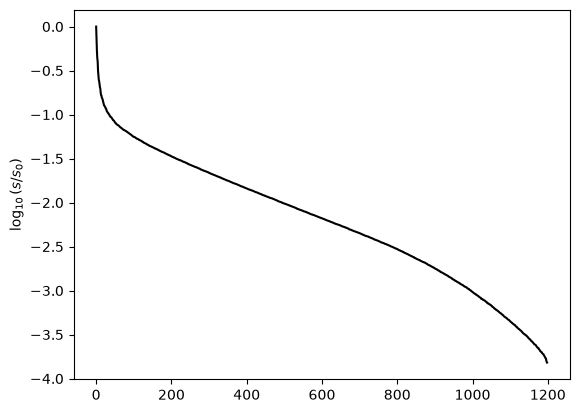

In [9]:
# Analyze singular values
smax = s[0]
s_log_scaled = np.ma.log10(s/smax)
plt.plot(s_log_scaled[:-1], color='k')
plt.ylabel(r"$\log_{10}(s/s_{0})$");

So looking at our rescaled singular values, we see that there is a precipitous drop off in magnitude after about the first 100 terms.  What if we only used these singular values and their affiliated vectors?  Doing this sort of thing in Python is really slick.  Watch...

In [10]:
indskp = np.log10(s/smax) >= -2 # We only keep singular values that are 1/100 the magnitude of the largest.  
skinny_puppy = u[:,indskp] @ np.diag( s[indskp] ) @ vh[indskp, :] + average_dog

If we look at the ratio of how many singular values we kept to how many we started with, we get a sense of the percentage of information we keep when we reduce data this way.  To wit...

In [11]:
compression_ratio = s[indskp].size/s.size
print("The compression ratio is {0:1.2f}%".format(compression_ratio*100.))

The compression ratio is 41.08%


So by truncating those singular values which are 1/100 the size of the largest, we only keep 41.17% of our original singular values.  Let's see what that gets us.

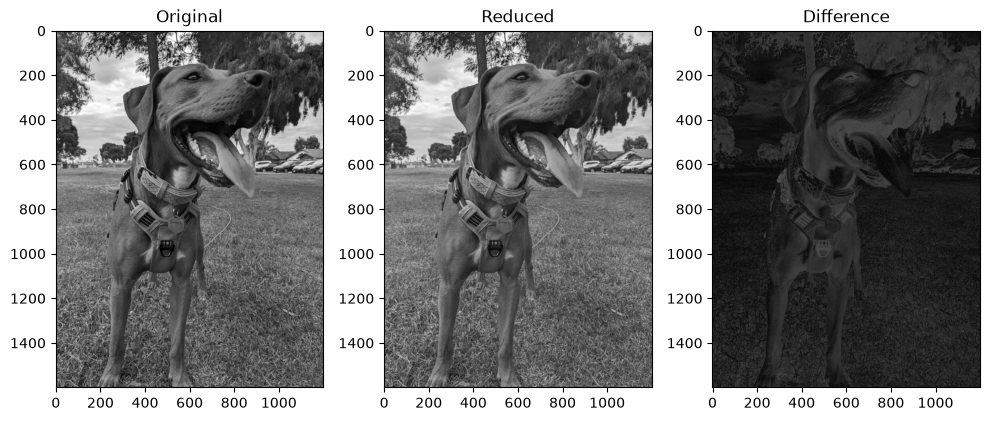

In [12]:
# How much puppy do we have left? Let's plot the original and reduced figures as well as the difference side-by-side
image_comparison(dog_grayscale, skinny_puppy)

So we certainly can see some differences between the original and reduced images, but the difference is an issue of crispness.  The reduced image is still clearly our original puppy.  Now let's see what happens if we push this argument a little too far. 

In [13]:
indskp = np.log10(s/smax) >= -1 # We only keep singular values that are 1/10 the magnitude of the largest.  
really_skinny_puppy = u[:,indskp] @ np.diag( s[indskp] ) @ vh[indskp, :] + average_dog
compression_ratio = s[indskp].size/s.size
print("The compression ratio is {0:1.2f}%".format(compression_ratio*100.))

The compression ratio is 2.92%


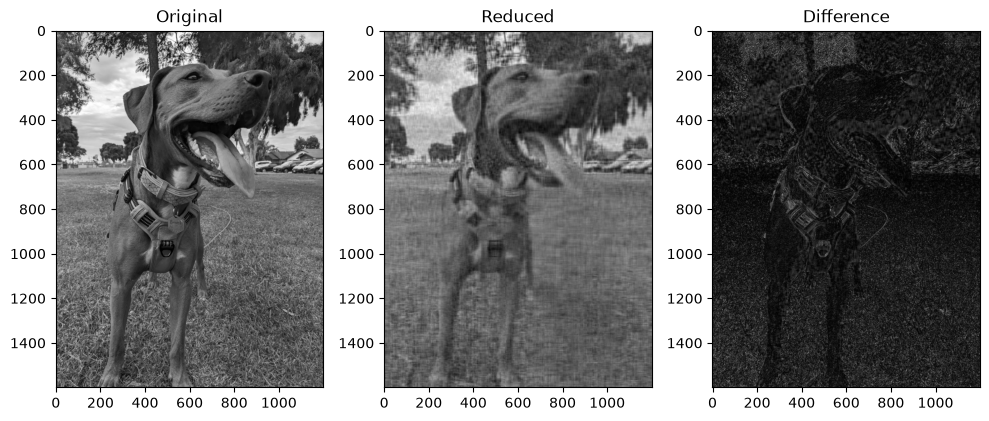

In [14]:
image_comparison(dog_grayscale, really_skinny_puppy)

Okay, by only taking 2.9% of our original image, our reduction still gives us a recognizable puppy.  